In [21]:
# --- STEP 1: IMPORT PACKAGES ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import graphviz 
import warnings

# Model Selection & Metrics
from sklearn import model_selection, tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.metrics import confusion_matrix, make_scorer, accuracy_score
from sklearn.impute import SimpleImputer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

# --- STEP 2: HELPER FUNCTIONS ---

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    
    # FIX: Added 'for' and comma correctly
    plt.xticks(tick_marks, [classes[i] for i in range(len(classes))], rotation=45)
    plt.yticks(tick_marks, [classes[i] for i in range(len(classes))])
    
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Definitions for your model names to stay organized
names = ["Nearest Neighbors", "Linear SVM", "RBF SVM", "Gaussian Process",
         "Decision Tree", "Random Forest", "MLPClassifier", "AdaBoost",
         "Naive Bayes", "QDA"]    

classifiers = [
    KNeighborsClassifier(),
    SVC(kernel="linear"),
    SVC(kernel="rbf"),
    GaussianProcessClassifier(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    MLPClassifier(),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis()
]

dict_characters = {0: 'Healthy', 1: 'Diabetes'}

Dataset Shape: (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Column Name          # of Zero Values
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


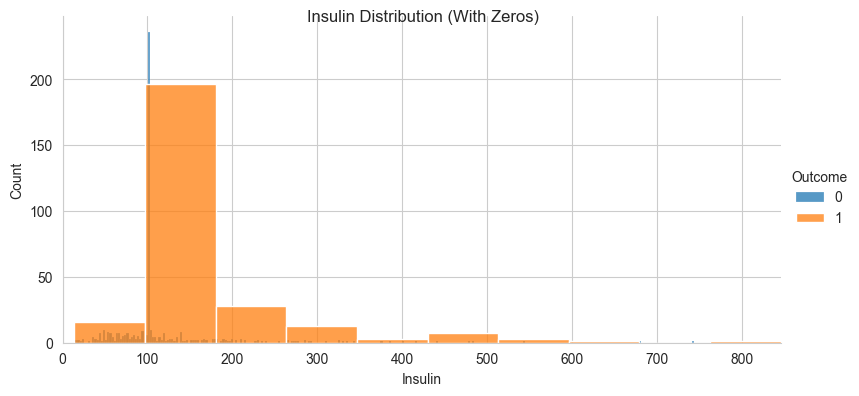


Zeros remaining in X_train after Imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [22]:
# --- 1. Load Data ---
# Using the literal path from your environment
dataset = pd.read_csv(r'C:\Academic Projects\DIABETES-DETECTION\diabetes.csv')

# --- 2. Initial Inspection ---
print("Dataset Shape:", dataset.shape)
print("\nFirst 5 Rows:")
print(dataset.head())

# --- 3. Identify Hidden Nulls (Zeros) ---
# Features where 0 is medically impossible/highly unlikely
features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nColumn Name          # of Zero Values")
print((dataset[features_with_zeros] == 0).sum())

# --- 4. Define Histogram Function ---
def plotHistogram(values, label, feature, title):
    sns.set_style("whitegrid")
    # FacetGrid to compare Healthy vs Diabetes distribution
    plotOne = sns.FacetGrid(values, hue=label, aspect=2, height=4)
    plotOne.map(sns.histplot, feature, kde=False) # Updated distplot to histplot
    plotOne.set(xlim=(0, values[feature].max()))
    plotOne.add_legend()
    plotOne.set_axis_labels(feature, 'Count')
    plotOne.fig.suptitle(title)
    plt.show()

# Visualize before imputation (to show the "Zero" spikes)
plotHistogram(dataset, "Outcome", 'Insulin', 'Insulin Distribution (With Zeros)')

# --- 5. Data Splitting & Imputation ---
# Split Features and Target
X = dataset.drop('Outcome', axis=1)
y = dataset['Outcome']

# Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Initialize SimpleImputer to replace 0 with Median
# Strategy: Median is safer than Mean for skewed medical data (like Insulin)
imputer = SimpleImputer(missing_values=0, strategy='median')

# Fit on training data ONLY, then transform both to prevent data leakage
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame for visualization and future steps
X_train_final = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_final = pd.DataFrame(X_test_imputed, columns=X.columns)

# Verify no zeros remain in critical columns
print("\nZeros remaining in X_train after Imputation:")
print((X_train_final[features_with_zeros] == 0).sum())


--- Algorithm Comparison: K-Fold Cross-Validation Accuracy ---
   Nearest Neighbors | Mean Accuracy: 85.35% (+/- 4.25%)
          Linear SVM | Mean Accuracy: 78.83% (+/- 4.17%)
             RBF SVM | Mean Accuracy: 85.02% (+/- 4.62%)
    Gaussian Process | Mean Accuracy: 84.70% (+/- 4.91%)
       Decision Tree | Mean Accuracy: 83.86% (+/- 4.01%)
       Random Forest | Mean Accuracy: 85.67% (+/- 4.22%)
       MLPClassifier | Mean Accuracy: 80.45% (+/- 4.94%)
            AdaBoost | Mean Accuracy: 85.83% (+/- 3.18%)
         Naive Bayes | Mean Accuracy: 75.90% (+/- 6.20%)
                 QDA | Mean Accuracy: 74.92% (+/- 6.35%)


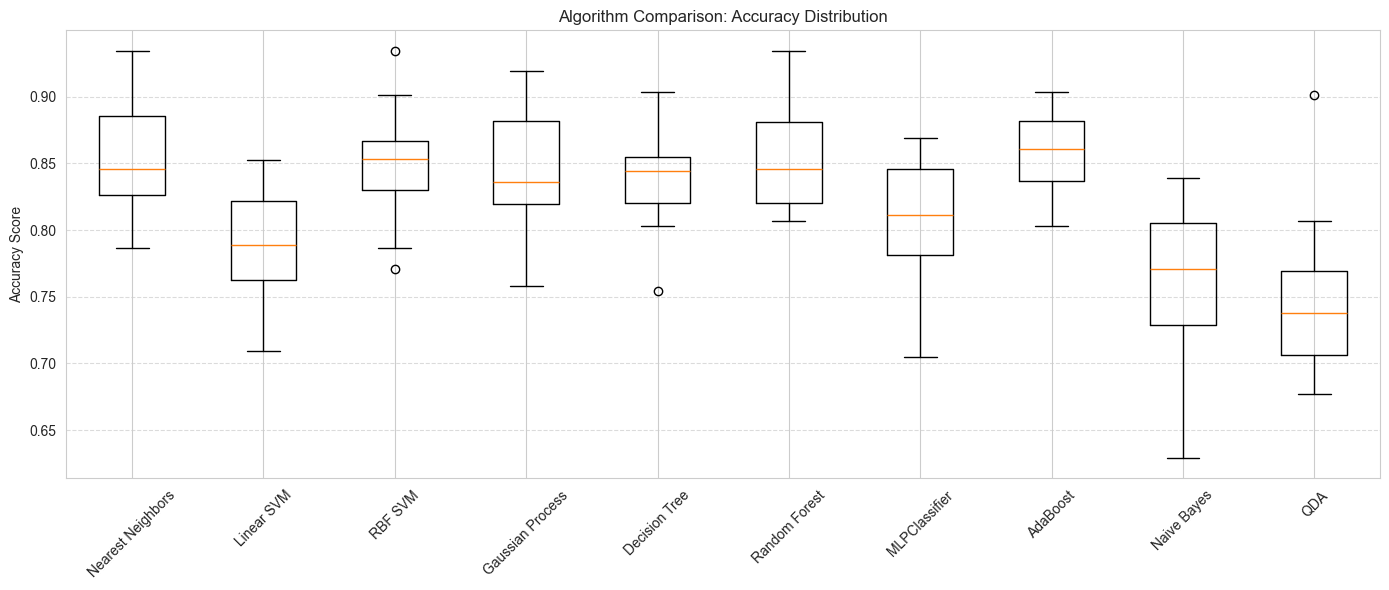

In [23]:
# --- 1. The Comparison Function ---
def compareABunchOfDifferentModelsAccuracy(X_train, y_train):
    print('\n--- Algorithm Comparison: K-Fold Cross-Validation Accuracy ---')
    
    resultsAccuracy = []
    
    # Use zip to iterate through names and classifiers defined in Step 2
    for name, model in zip(names, classifiers):
        # KFold with shuffle=True is best practice for randomized datasets
        kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)
        
        # Cross-validation on the TRAINING data
        accuracy_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
        resultsAccuracy.append(accuracy_results)
        
        # Calculate and print Mean and Standard Deviation
        mean_acc = accuracy_results.mean() * 100
        std_acc = accuracy_results.std() * 100
        print(f"{name:>20} | Mean Accuracy: {mean_acc:.2f}% (+/- {std_acc:.2f}%)")

    # --- 2. Boxplot Visualization ---
    plt.figure(figsize=(14, 6))
    plt.title('Algorithm Comparison: Accuracy Distribution')
    plt.boxplot(resultsAccuracy)
    
    # Set labels and rotate for readability
    plt.xticks(range(1, len(names) + 1), names, rotation=45)
    plt.ylabel('Accuracy Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- 3. EXECUTE ---
# We use X_train_final and y_train from the previous step
compareABunchOfDifferentModelsAccuracy(X_train_final, y_train)

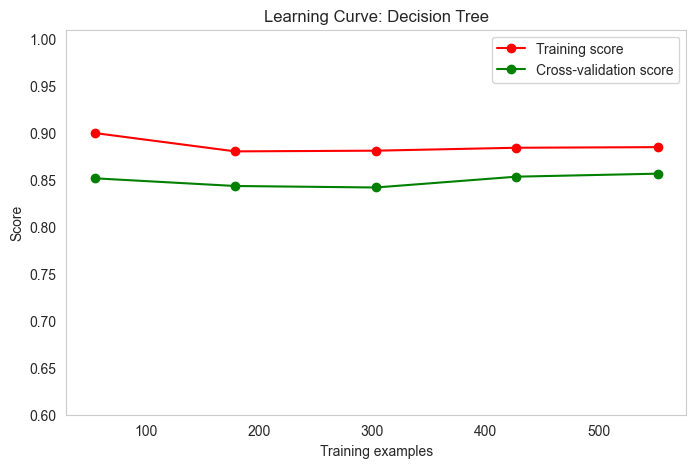

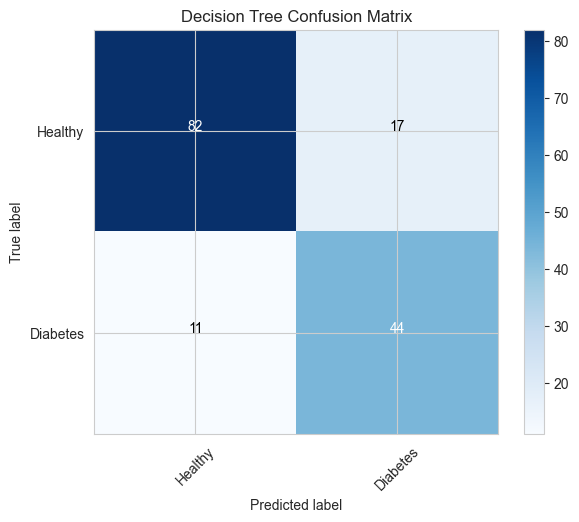

Decision Tree - CV Mean Accuracy: 85.67% (+/- 4.29%)


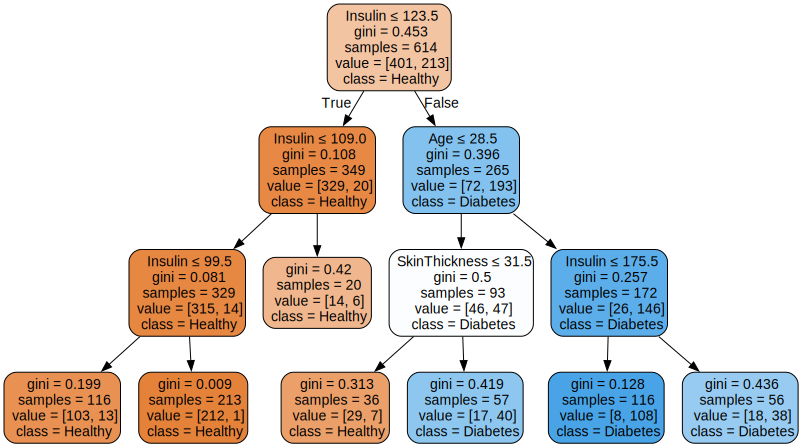

In [24]:
import os
from sklearn.tree import export_graphviz

# --- 1. Decision Tree Training and Detailed Evaluation ---
def runDecisionTree(X_train, y_train, X_test, y_test):
    # Initialize the model
    # Note: max_depth=3 prevents overfitting and makes the tree readable for exams
    model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=12)
    model.fit(X_train, y_train)
    
    # K-Fold Evaluation
    kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)
    accuracy = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    
    # Predictions for Confusion Matrix
    prediction = model.predict(X_test)
    cnf_matrix = confusion_matrix(y_test, prediction)

    # Visualization 1: Learning Curve
    # Shows if we need more data or if the model is already "saturated"
    plot_learning_curve(model, 'Learning Curve: Decision Tree', X_train, y_train, ylim=(0.6, 1.01), cv=kfold)
    plt.show()
    
    # Visualization 2: Confusion Matrix
    # Shows True Positives (Diabetes correctly identified) vs False Positives
    plt.figure(figsize=(6, 5))
    plot_confusion_matrix(cnf_matrix, classes=dict_characters, title='Decision Tree Confusion Matrix')
    plt.show()

    print(f'Decision Tree - CV Mean Accuracy: {accuracy.mean()*100:.2f}% (+/- {accuracy.std()*100:.2f}%)')
    return model

# Run the detailed evaluation
dt_model = runDecisionTree(X_train_final, y_train, X_test_final, y_test)

# --- 2. Graphical Tree Visualization ---
def plot_graphical_tree(model, feature_names):
    # Export tree to dot format
    dot_data = export_graphviz(model, out_file=None, 
                               feature_names=feature_names,  
                               class_names=['Healthy', 'Diabetes'],  
                               filled=True, 
                               rounded=True,  
                               special_characters=True)  
    
    # Render using Graphviz
    graph = graphviz.Source(dot_data)  
    return graph 

# Display the tree structure
# This will show which features (like Glucose) are the most important "splitters"
tree_graph = plot_graphical_tree(dt_model, X.columns)
tree_graph


--- Identifying Top Performers Dynamically ---
Rank 1: Random Forest (86.48%)
Rank 2: AdaBoost (85.83%)
Rank 3: Nearest Neighbors (85.35%)
Rank 4: RBF SVM (85.02%)
Rank 5: Gaussian Process (84.70%)

Automatically selecting Random Forest and AdaBoost for Hybrid Model.

--- DYNAMIC HYBRID PERFORMANCE ---
Hybrid Accuracy: 88.96%

--- Random Forest Feature Importance ---
                   Variable  Importance
4                   Insulin    0.366537
3             SkinThickness    0.168331
1                   Glucose    0.148814
5                       BMI    0.080102
7                       Age    0.079649
6  DiabetesPedigreeFunction    0.064366
0               Pregnancies    0.046702
2             BloodPressure    0.045500


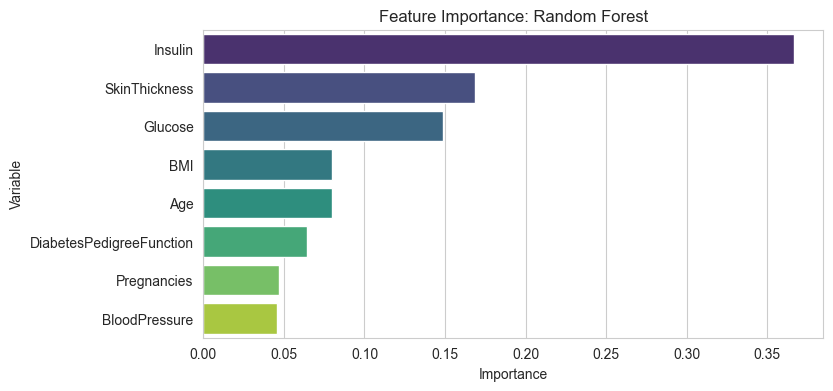

In [25]:
# --- 1. Dynamic Model Evaluation ---
def get_best_models(X, y):
    print('\n--- Identifying Top Performers Dynamically ---')
    model_scores = []
    
    for name, model in zip(names, classifiers):
        kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)
        cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
        
        model_scores.append({
            'name': name,
            'model': model,
            'score': cv_results.mean()
        })
    
    sorted_models = sorted(model_scores, key=lambda x: x['score'], reverse=True)
    for i, m in enumerate(sorted_models[:5]): # Show top 5
        print(f"Rank {i+1}: {m['name']} ({m['score']*100:.2f}%)")
        
    return sorted_models

ranked_models = get_best_models(X_train_final, y_train)

# --- 2. Dynamic Hybrid Voting Model ---
top_1 = ranked_models[0]
top_2 = ranked_models[1]

print(f"\nAutomatically selecting {top_1['name']} and {top_2['name']} for Hybrid Model.")

dynamic_hybrid = VotingClassifier(
    estimators=[
        (top_1['name'].lower().replace(" ", "_"), top_1['model']), 
        (top_2['name'].lower().replace(" ", "_"), top_2['model'])
    ],
    voting='soft'
)

# Fit the Hybrid model
dynamic_hybrid.fit(X_train_final, y_train)
hybrid_acc = dynamic_hybrid.score(X_test_final, y_test) * 100

print(f"\n--- DYNAMIC HYBRID PERFORMANCE ---")
print(f"Hybrid Accuracy: {hybrid_acc:.2f}%")

# --- 3. Feature Importance (FIXED) ---
# We must FIT the top model individually before checking importances
best_model_obj = top_1['model']
best_model_obj.fit(X_train_final, y_train) # Added this to fix NotFittedError

# Check if the model supports feature_importances_ (KNN and SVM do not)
if hasattr(best_model_obj, 'feature_importances_'):
    print_feature_importance(best_model_obj, top_1['name'], X.columns)
else:
    print(f"\nNote: {top_1['name']} does not support direct feature importance visualization.")

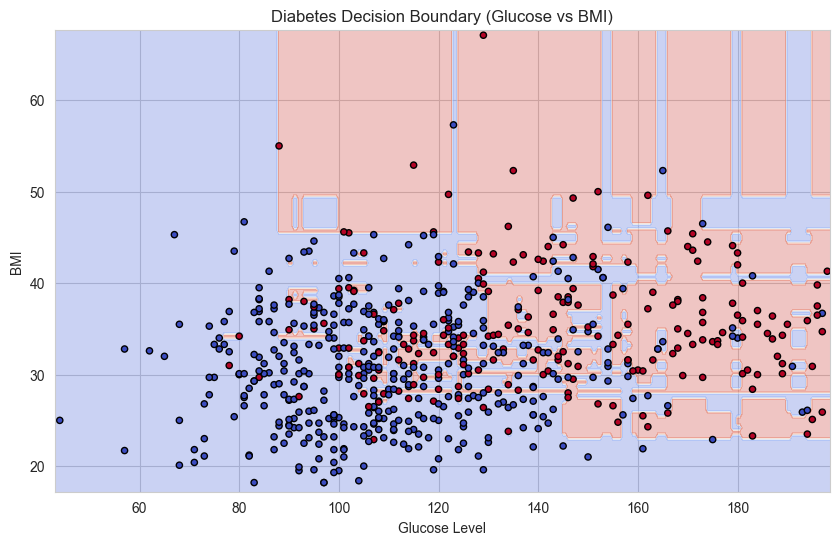

In [30]:
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    h = 0.5  # step size in the mesh
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training points
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=20)
    
    plt.xlabel('Glucose Level')
    plt.ylabel('BMI')
    plt.title('Diabetes Decision Boundary (Glucose vs BMI)')
    plt.show()

# Run the visualization for your reduced XGBoost model
plot_decision_boundary(clf_reduced, X_train_reduced, y_train)

In [32]:
# --- 1. Train the Individual XGBoost Model ---
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=1)
model_xgb.fit(X_train_final, y_train)
acc_xgb = model_xgb.score(X_test_final, y_test) * 100

# --- 2. Use the Dynamic Hybrid (from previous step) ---
# Note: dynamic_hybrid was already fitted in Step 6
acc_hybrid = dynamic_hybrid.score(X_test_final, y_test) * 100

print(f"Individual XGBoost Accuracy: {acc_xgb:.2f}%")
print(f"Dynamic Hybrid Accuracy:    {acc_hybrid:.2f}%")

# --- 3. THE SELECTION LOGIC ---
if acc_xgb > acc_hybrid:
    final_model = model_xgb
    selection_name = "XGBoost"
    print(f"\n>>> FINAL SELECTION: {selection_name} (Highest Accuracy)")
else:
    final_model = dynamic_hybrid
    selection_name = "Dynamic Hybrid"
    print(f"\n>>> FINAL SELECTION: {selection_name} (Better Stability/Accuracy)")

# --- 4. Final Verification ---
print(f"Successfully selected {selection_name} for deployment.")

Individual XGBoost Accuracy: 89.61%
Dynamic Hybrid Accuracy:    88.96%

>>> FINAL SELECTION: XGBoost (Highest Accuracy)
Successfully selected XGBoost for deployment.


In [33]:
import joblib
import json

# --- 1. Save the Winning Model (The Champion) ---
# This 'final_model' was decided by your selection logic in Step 7
model_filename = 'final_diabetes_model.pkl'
joblib.dump(final_model, model_filename)

# --- 2. Save the Imputer (CRITICAL) ---
# Without this, your backend cannot handle the 0-values in new patient data
imputer_filename = 'diabetes_imputer.pkl'
joblib.dump(imputer, imputer_filename)

# --- 3. Save Metadata for app.py ---
metadata = {
    "selected_model": selection_name,
    "accuracy": max(acc_xgb, acc_hybrid),
    "features": list(X.columns)
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)

print(f"--- BACKEND ASSETS READY ---")
print(f"1. Model Saved: {model_filename}")
print(f"2. Imputer Saved: {imputer_filename}")
print(f"3. Info: Using {selection_name} with {metadata['accuracy']:.2f}% accuracy.")

--- BACKEND ASSETS READY ---
1. Model Saved: final_diabetes_model.pkl
2. Imputer Saved: diabetes_imputer.pkl
3. Info: Using XGBoost with 89.61% accuracy.


In [34]:
import joblib
import json

# 1. Save the CHAMPION Model (The Winner selected in Step 7)
# This could be XGBoost or the Dynamic Hybrid depending on your accuracy results.
model_path = 'final_diabetes_model.pkl'
joblib.dump(final_model, model_path)

# 2. Save the IMPUTER (This is the most common mistake in student projects!)
# The backend MUST use the same medians as the training set to handle 0-values.
imputer_path = 'diabetes_imputer.pkl'
joblib.dump(imputer, imputer_path)

# 3. Create a Metadata JSON (For your project report and Backend UI)
project_metadata = {
    "Project Name": "DiaPredict",
    "Selected Model": selection_name,
    "Final Test Accuracy": f"{max(acc_xgb, acc_hybrid):.2f}%",
    "Developed By": "Sakshi Gharat",
    "College": "Terna Engineering College"
}

with open('model_metadata.json', 'w') as f:
    json.dump(project_metadata, f)

print("--- BACKEND ASSETS GENERATED ---")
print(f"✓ Model: {model_path}")
print(f"✓ Imputer: {imputer_path}")
print(f"✓ Metadata: model_metadata.json")

--- BACKEND ASSETS GENERATED ---
✓ Model: final_diabetes_model.pkl
✓ Imputer: diabetes_imputer.pkl
✓ Metadata: model_metadata.json
